In [1]:
import urllib.request
import json

import paths
import importlib
import xarray as xr
import os
import pandas as pd


from matplotlib import gridspec
from download_data import nrfa_api, download_shapefiles, download_nrfa
from train_model import load_data, train
from preprocessing import catchment_characteristics as cc

importlib.reload(paths)
importlib.reload(nrfa_api)
importlib.reload(download_shapefiles)
importlib.reload(train)

<module 'train_model.train' from '/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/train_model/train.py'>

In [3]:
station_ids = nrfa_api.get_all_stations_id()
print(len(station_ids))

1601


In [4]:
def update_rain_status(log_path, data_dir):
    """
    Update the log file: if id_nrfa.csv is missing for a station,
    set rain_success to False and status to 'partial'.

    Parameters
    ----------
    log_path : str
        Path to the JSON log file.
    data_dir : str
        Directory where `id_nrfa.csv` files are expected.

    Returns
    -------
    None. Updates the log file in-place.
    """
    # Load log
    with open(log_path, 'r') as f:
        log = json.load(f)

    updated = False
    for sid, entry in log.items():
        csv_path = os.path.join(data_dir, sid, f"{sid}_nrfa.csv")
        print(csv_path)
        if not os.path.exists(csv_path):
            if entry.get("rain_success", True) or entry.get("status") == "success":
                entry["rain_success"] = False
                entry["status"] = "partial"
                updated = True
                print(f"⚠️ Missing: {sid}_nrfa.csv → marked as partial")
        else:
            entry["rain_success"] = True
            entry["status"] = "success"

    # Save only if there were changes
    if updated:
        with open(log_path, 'w') as f:
            json.dump(log, f, indent=2)
        print("✅ Log updated and saved.")
    else:
        print("✔️ All files present. No changes made.")

In [5]:
download_nrfa.download_csv(57010, 'cdr')

57010
https://nrfaapps.ceh.ac.uk/nrfa/ws/time-series?station=57010&data-type=cdr&format=json-object


True

In [6]:
update_rain_status(download_nrfa.LOG_IDS_PATH, paths.CATCHMENT_BASINS)

/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/2001/2001_nrfa.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/3002/3002_nrfa.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/3003/3003_nrfa.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/3004/3004_nrfa.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/4001/4001_nrfa.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/4003/4003_nrfa.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/6007/6007_nrfa.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/600

In [7]:
xr.open_dataset(paths.WEATHER_UK + '/Rainfall/Rainfall_2021_aggregated_9to9.nc')

<xarray.Dataset> Size: 7MB
Dimensions:     (valid_time: 365, latitude: 49, longitude: 49)
Coordinates:
    number      int64 8B ...
  * latitude    (latitude) float64 392B 60.0 59.75 59.5 ... 48.5 48.25 48.0
  * longitude   (longitude) float64 392B -8.0 -7.75 -7.5 -7.25 ... 3.5 3.75 4.0
  * valid_time  (valid_time) datetime64[ns] 3kB 2021-01-01 ... 2021-12-31
Data variables:
    tp          (valid_time, latitude, longitude) float32 4MB ...
    smlt        (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-02T13:16 GRIB to CDM+CF via cfgrib-0.9.1...

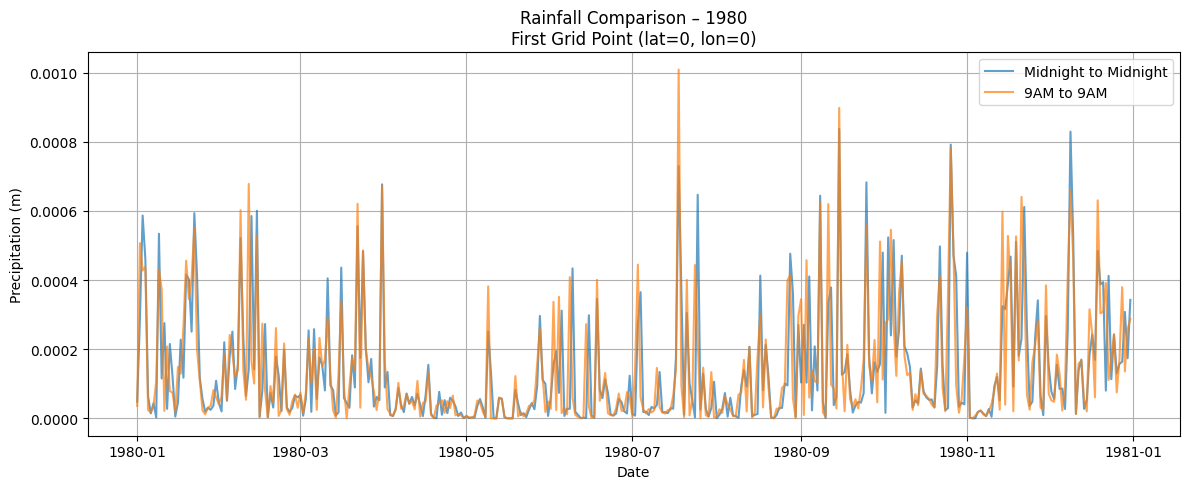

In [8]:
import xarray as xr
import matplotlib.pyplot as plt

# File paths (adjust if needed)
yy = 1980
base_path = paths.WEATHER_UK + f"/Rainfall/Rainfall_{yy}"
file_normal = base_path + "_aggregated.nc"
file_9to9   = base_path + "_9to9.nc"

# Load datasets
ds_normal = xr.open_dataset(file_normal)
ds_9to9 = xr.open_dataset(file_9to9)

# Extract first lat/lon point
rain_normal = ds_normal.tp.isel(latitude=0, longitude=0)
rain_9to9 = ds_9to9.tp.isel(latitude=0, longitude=0)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(rain_normal.valid_time, rain_normal, label='Midnight to Midnight', alpha=0.7)
plt.plot(rain_9to9.valid_time, rain_9to9, label='9AM to 9AM', alpha=0.7)

plt.title("Rainfall Comparison – 1980\nFirst Grid Point (lat=0, lon=0)")
plt.xlabel("Date")
plt.ylabel("Precipitation (m)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
import matplotlib.pyplot as plt

# Select the 24 hourly values for 1990-12-30
subset = original.tp.sel(
    valid_time=slice('1990-12-30T00:00', '1990-12-30T23:59')
).isel(latitude=1, longitude=0)

# Plot
plt.figure(figsize=(10, 4))
subset.plot(marker='o')
plt.title("Hourly Precipitation on 1990-12-30\n(lat=1, lon=0)")
plt.ylabel("Precipitation (m)")
plt.xlabel("Time (UTC)")
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'original' is not defined

In [10]:
original.tp.sel(valid_time='1990-12-30').isel(latitude=1, longitude=0).sum(dim='valid_time')

NameError: name 'original' is not defined

In [11]:
daily_rainfall_9to9.sel(floor='1990-12-30').isel(latitude=1, longitude=0)

NameError: name 'daily_rainfall_9to9' is not defined

In [12]:
filename = paths.WEATHER_UK + f'/Rainfall/Rainfall_{yy}_aggregated.nc'
aggregated = xr.open_dataset(filename)
aggregated.tp.values

array([[[4.82996293e-05, 4.57366295e-05, 4.31736298e-05, ...,
         1.43408775e-04, 7.28368759e-05, 4.86373901e-05],
        [5.30083962e-05, 4.98493500e-05, 4.64717559e-05, ...,
         1.47481755e-04, 8.57512132e-05, 5.87701797e-05],
        [5.61277084e-05, 5.20149879e-05, 4.82002906e-05, ...,
         2.00351074e-04, 1.36792660e-04, 9.31819304e-05],
        ...,
        [6.03795052e-05, 7.40488395e-05, 8.65459442e-05, ...,
         2.90075945e-06, 3.53654218e-06, 4.45047999e-06],
        [5.37435226e-05, 7.34925270e-05, 8.74996185e-05, ...,
         2.40405393e-06, 3.05970502e-06, 4.29153442e-06],
        [5.06838151e-05, 6.56048433e-05, 8.02675859e-05, ...,
         2.12589907e-06, 1.94708514e-06, 2.76168180e-06]],

       [[2.87771225e-04, 2.47180462e-04, 2.06629440e-04, ...,
         2.75174771e-05, 3.23255845e-05, 1.82986259e-05],
        [2.95639038e-04, 2.61882931e-04, 2.30352089e-04, ...,
         3.09745483e-05, 4.28160020e-05, 2.56896019e-05],
        [3.09785217e-04, 

In [13]:
aggregated.tp.sel(valid_time='1990-12-30').isel(latitude=1, longitude=0)

KeyError: "not all values found in index 'valid_time'. Try setting the `method` keyword argument (example: method='nearest')."

In [ ]:
"""
    if not os.path.exists(filename + '_9to9.nc'):
        print('shifting', filename)
        er.shift_time_9am_to_9am(str(rain_query['file_stem']) + '.nc',
                                 int(yy),
                                 str(rain_query['file_stem']) + '_9to9.nc')
        er.aggregate_mean(str(rain_query['file_stem']) + '_9to9.nc',
                          str(rain_query['file_stem']) + '_aggregated_9to9.nc',
                          shift=9)
"""

In [14]:
file_robert = pd.read_csv(paths.DATA + '/nrfa-station-metadata.csv')
file_robert

,id,name,catchment-area,easting,northing,latitude,longitude,river,location,station-level,...,mean-flood-plain-depth,mean-flood-plain-location,mean-flood-plain-extent,urbext-1990,urbconc-1990,urbloc-1990,urbext-2000,urbconc-2000,urbloc-2000,data-summary
0,1001,Wick at Tarroul,161.9,326202.0,954915.0,58.47620,-3.26706,Wick,Tarroul,13.0,...,0.763,0.928,0.0922,0.0004,NaN,NaN,0.0012,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d
1,2001,Helmsdale at Kilphedir,551.4,299839.0,918163.0,58.14100,-3.70295,Helmsdale,Kilphedir,17.0,...,0.671,1.069,0.0555,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
2,2002,Brora at Bruachrobie,434.4,289156.0,903916.0,58.01056,-3.87757,Brora,Bruachrobie,9.0,...,0.705,1.024,0.0553,0.0000,NaN,NaN,0.0002,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
3,3001,Shin at Lairg,494.6,258100.0,906200.0,58.02222,-4.40405,Shin,Lairg,81.7,...,0.742,0.893,0.0621,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d
4,3002,Carron at Sgodachail,241.1,249136.0,892152.0,57.89321,-4.54668,Carron,Sgodachail,70.7,...,0.633,0.863,0.0377,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,206002,Jerretspass at Jerretspass,107.8,306487.0,333187.0,54.23652,-6.36758,Jerretspass,Jerretspass,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gdf;gmf
1597,206006,Annalong at Recorder,13.8,335000.0,323100.0,54.13925,-5.93509,Annalong,Recorder,NaN,...,0.292,0.820,0.0230,0.0000,NaN,NaN,0.0000,NaN,NaN,cmr;cdr;cdr-d;pot-flow;amax-flow
1598,236005,Colebrooke at Ballindarragh Bridge,313.6,233195.0,335906.0,54.27093,-7.49124,Colebrooke,Ballindarragh Bridge,53.0,...,0.878,0.811,0.0819,0.0067,NaN,0.645,0.0012,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
1599,236007,Sillees at Drumrainey Bridge,166.3,220486.0,340003.0,54.30840,-7.68602,Sillees,Drumrainey Bridge,44.0,...,2.282,0.844,0.1622,0.0020,NaN,NaN,0.0006,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...


In [15]:
full_pressure_data = xr.open_mfdataset(paths.WEATHER_UK + '/Pressure/Pressure_*.nc', concat_dim='valid_time', combine='nested', engine='netcdf4')

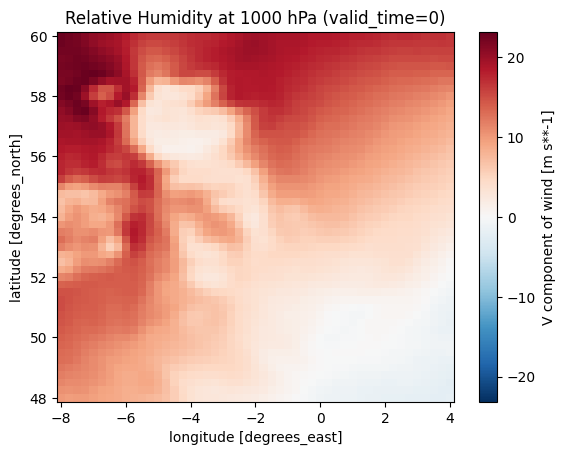

In [20]:
import xarray as xr
import matplotlib.pyplot as plt

# Open the file
ds = xr.open_dataset(paths.DATA + '/weather_UK/Pressure/Pressure_20071000hPa.nc')
ds = full_pressure_data 

# Choose a time slice and squeeze singleton dims
r = ds['v'].sel(pressure_level=1000).isel(valid_time=50).squeeze()

# Plot as 2D map
r.plot()
plt.title("Relative Humidity at 1000 hPa (valid_time=0)")
plt.show()

In [175]:
all_files = os.listdir(paths.PREDICTIONS + '/era5')

# Filter only *_era5.csv files and extract station numbers
station_numbers = [
    filename.split('_')[0]
    for filename in all_files
    if filename.endswith('_era5.csv')
]

In [210]:
importlib.reload(cc)

<module 'preprocessing.catchment_characteristics' from '/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/preprocessing/catchment_characteristics.py'>

In [221]:
## PERFORMANCE PLOT

input_type = 'era5'

overview_gdf = cc.get_characteristics_all_stations(station_numbers, 
                                                   input_type=input_type, 
                                                   years_eval=years_eval)
"""
params_to_plot = ['Area', 'Latitude', 'HE_mean', 'Slope gradient']
labels_to_plot = ['Catchment Area [m^2]', 'Latitude [°]', 'Hydrological Efficiency [mm/day]', 'Slope gradient [%]']
colormap_param = 'Latitude' #'90 percentile'
"""

params_to_plot = ['Latitude']
labels_to_plot = ['Latitude [°]']
colormap_param = 'Latitude' 

catchment_dict ={'7001':'Findhorn',
                 '33039':'Bedford Ouse',
                 '54057':'Severn'}

fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.015])
axes = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(4)]

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(overview_gdf[colormap_param].min(), overview_gdf[colormap_param].max())

# Plot each parameter in its respective subplot
for i, param in enumerate(params_to_plot):
    if i < 4:
        sc = axes[i].scatter(overview_gdf[param], overview_gdf['NSE'], c=overview_gdf[colormap_param], cmap=cmap, norm=norm, marker='o', s=35)
        axes[i].set_xlabel(labels_to_plot[i], weight='bold', size=12)
        if i == 1 or i == 23:
            axes[i].set_yticklabels([])
            
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].tick_params(axis='both', labelsize=12)
        
        # Add station names next to the focus catchments
        for j, row in overview_gdf.iterrows():
            if row['Station'] in ['7001','33039','54057']:
                x_offset = (overview_gdf[param].max()-overview_gdf[param].min())/100
                y_offset = 0.01
                axes[i].text(row[param] + x_offset, row['NSE'] + y_offset, catchment_dict.get(row['Station']), fontsize=11, ha='left')
        
        axes[i].grid(True)

# Add colorbar to indicate latitude
cax = fig.add_subplot(gs[:, 2]) 
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='vertical', label='Altitude [m]')
cbar.ax.yaxis.label.set_weight('bold')
cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.label.set_size(12)
fig.supylabel('Normalized Squared Error (NSE)', weight='bold', size=12)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [222]:
import matplotlib.pyplot as plt

def plot_prediction(df_predictions, variable_to_plot):
    df_predictions['Date'] = pd.to_datetime(df_predictions['Date'])

    plt.figure(figsize=(10, 4))
    plt.plot(df_predictions['Date'], df_predictions[variable_to_plot], label='Predicted Flow')
    plt.xlabel('Date')
    plt.ylabel('Flow')
    plt.title('Streamflow Prediction')
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [223]:
df_predictions = pd.read_csv(paths.CATCHMENT_BASINS + '/2001/2001_lumped_nrfa.csv')
#df_predictions = pd.read_csv(paths.PREDICTIONS + '/era5/8006_era5.csv')

In [224]:
df_predictions['Parsed_Date'] = pd.to_datetime(df_predictions['Date'], errors='coerce')

# Find rows where the conversion failed (invalid dates)
invalid_date_rows = df_predictions[df_predictions['Parsed_Date'].isna()]
invalid_date_rows

,Unnamed: 0.1,Date,Rain,Rain-1,Rain-2,Rain-3,Rain-4,Rain-5,Rain-6,Rain-7,...,Humidity-22,Humidity-23,Humidity-24,Humidity-25,Humidity-26,Humidity-27,Humidity_28_Mu,Humidity_90_Mu,Humidity_180_Mu,Parsed_Date


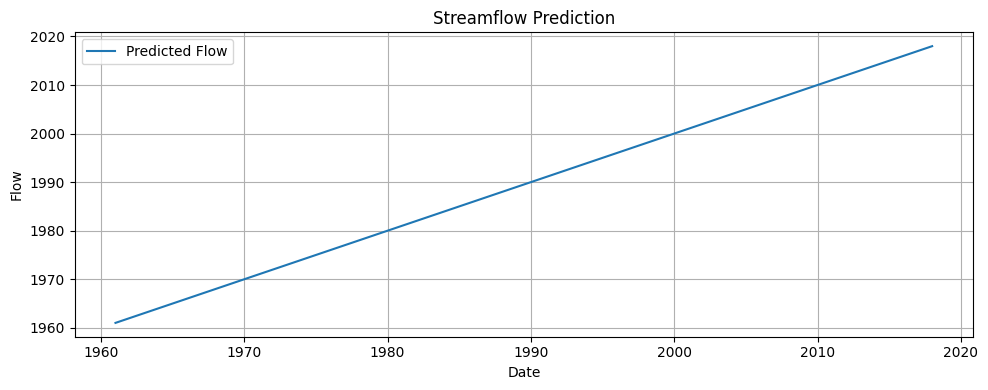

In [190]:
plot_prediction(df_predictions, 'Date')

In [188]:
df_predictions.columns

Index(['Unnamed: 0.1', 'Date', 'Rain', 'Rain-1', 'Rain-2', 'Rain-3', 'Rain-4',
       'Rain-5', 'Rain-6', 'Rain-7',
       ...
       'Humidity-21', 'Humidity-22', 'Humidity-23', 'Humidity-24',
       'Humidity-25', 'Humidity-26', 'Humidity-27', 'Humidity_28_Mu',
       'Humidity_90_Mu', 'Humidity_180_Mu'],
      dtype='object', length=165)

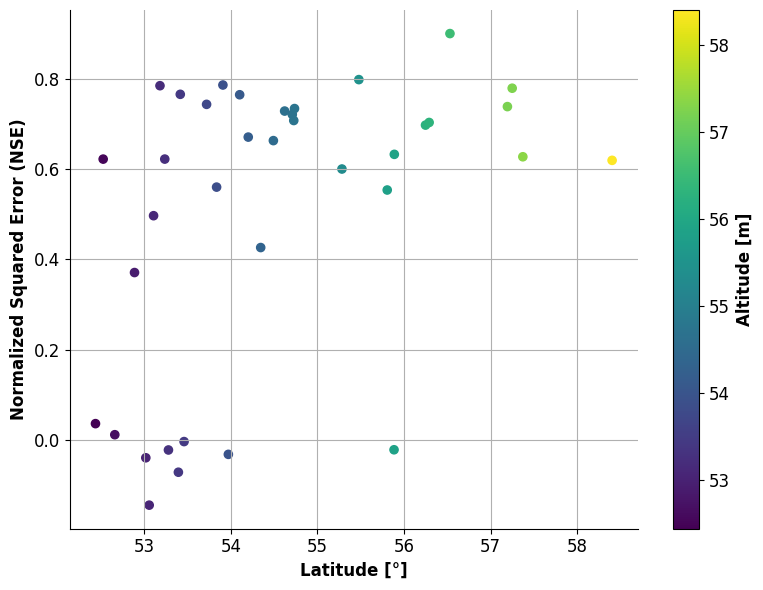

In [225]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl

input_type = 'era5'

overview_gdf = cc.get_characteristics_all_stations(
    station_numbers, 
    input_type=input_type, 
    years_eval=years_eval
)

# Set the parameter and label
param = 'Latitude'
label = 'Latitude [°]'
colormap_param = 'Latitude'  # Can change to another param if needed

catchment_dict = {
    '7001': 'Findhorn',
    '33039': 'Bedford Ouse',
    '54057': 'Severn'
}

# Set up figure
fig, ax = plt.subplots(figsize=(8, 6))

# Create color map
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(overview_gdf[colormap_param].min(), overview_gdf[colormap_param].max())

# Scatter plot
sc = ax.scatter(
    overview_gdf[param], 
    overview_gdf['NSE'], 
    c=overview_gdf[colormap_param], 
    cmap=cmap, 
    norm=norm,
    s=35
)

ax.set_xlabel(label, weight='bold', size=12)
ax.set_ylabel('Normalized Squared Error (NSE)', weight='bold', size=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True)

# Add station names next to the selected catchments
x_offset = (overview_gdf[param].max() - overview_gdf[param].min()) / 100
y_offset = 0.01
for _, row in overview_gdf.iterrows():
    if row['Station'] in catchment_dict:
        ax.text(row[param] + x_offset, row['NSE'] + y_offset, catchment_dict[row['Station']], fontsize=11, ha='left')

# Add colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
cbar.set_label('Altitude [m]', weight='bold', size=12)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [226]:
overview_era5_gdf = cc.get_characteristics_all_stations( station_numbers, 
    input_type='era5', 
    years_eval=years_eval
)

overview_nrfa_gdf = cc.get_characteristics_all_stations(station_numbers, 
    input_type='nrfa', 
    years_eval=years_eval
)

comparison = overview_era5_gdf.merge(overview_nrfa_gdf[['Station', 'NSE']], on='Station')
comparison = comparison.rename(columns={'NSE_x':'NSE_Era5', 'NSE_y':'NSE_NRFA'})

comparison['model_difference'] = comparison['NSE_NRFA'] - comparison['NSE_Era5']

/var/folders/zx/t4x2p2md0y3_5gs01s3cq2gm0000gq/T/ipykernel_91976/3010167027.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(latitude_labels, rotation=45, fontsize=12)


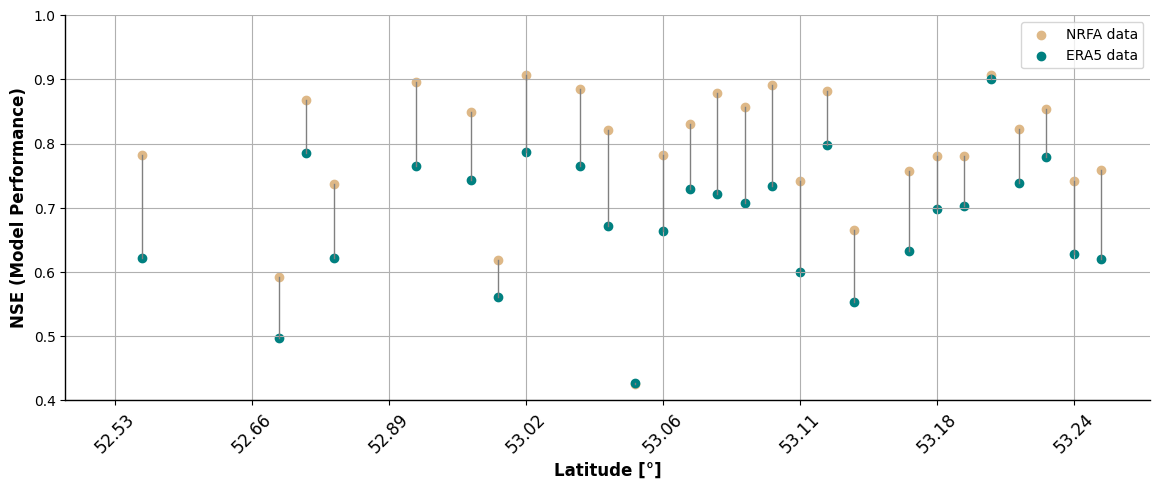

In [228]:
# Sort Dataframe by latitude
sort_param = 'Latitude'#'90 percentile'
comparison = comparison.sort_values(by=sort_param).reset_index(drop=True)
latitude_labels = [round(value, 2) for value in comparison[sort_param]]

catchment_dict ={'7001':'Findhorn',
                 '33039':'Bedford Ouse',
                 '54057':'Severn'}

fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot NSE values for Era5 and NRFA as dots
ax1.scatter(comparison.index, comparison['NSE_NRFA'], color='BurlyWood', label='NRFA data')
ax1.scatter(comparison.index, comparison['NSE_Era5'], color='Teal', label='ERA5 data')

# Draw lines between each pair of dots
for i in range(len(comparison)):
    ax1.plot([i, i], [comparison['NSE_Era5'].iloc[i], comparison['NSE_NRFA'].iloc[i]], color='gray', linestyle='-', linewidth=1)
    
# Add station names next to the focus catchments
param = 'NSE_NRFA'
for j, row in comparison.iterrows():
    if row['Station'] in ['7001','33039','54057']:
        x_offset = 0.1
        y_offset = 0.025
        ax1.text(j + x_offset, row[param] + y_offset, catchment_dict.get(row['Station']), fontsize=9, ha='center')

# Labels and title for the first axis
ax1.set_xlabel('Latitude [°]', fontweight='bold', fontsize=12)
ax1.set_ylabel('NSE')
ax1.set_xticklabels(latitude_labels, rotation=45, fontsize=12)
ax1.set_ylim(0.4,1)
ax1.set_ylabel('NSE (Model Performance)', fontweight='bold', fontsize=12)
ax1.legend(loc='upper right')

ax1.spines['bottom'].set_linewidth(1)
ax1.spines['left'].set_linewidth(1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('black')
ax1.spines['left'].set_color('black')

plt.grid(True)
#plt.savefig(f"{paths.IMAGES}/nrfa_vs_era5_modelperformance.png", dpi=300, bbox_inches='tight')
plt.show()